# HitPredict: Predicting Billboard Hits Using Spotify Data
**Team 21 · UE24CS352A · E Section**  
N S RAJ NANJAPPA (PES1UG24CS287) and NAGARAJ HEGDE (PES1UG24CS288)

This notebook documents a completed experiment using the original Stanford HitPredict CSV. It classifies inherited historical labels. It does not establish a prospective probability of future chart success.

**Question:** How well can nine audio features distinguish the source's hit and non-hit labels when test artists do not appear in training?

The code implementation is new. Dataset credit: Elena Georgieva, Marcella Suta and Nicholas Burton, [Stanford CS229, 2018](https://cs229.stanford.edu/proj2018/report/16.pdf).

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data import FEATURES, load_clean, split_data
from src.predict import load_bundle, score_frame
pd.set_option('display.max_columns', 15)
RUN_TRAINING = False
if RUN_TRAINING:
    from src.train import main
    main()
metrics = json.loads((ROOT / 'results/metrics.json').read_text())
print('Selected model:', metrics['selected_model'])
print('Random seed:', metrics['seed'])

Selected model: Random forest depth=16
Random seed: 21


## 1. Source data and audit
The no-date CSV has 4,040 rows. We normalize artist/title text and remove duplicate song keys. Labels come from the original authors. A source non-hit is not proof of never charting. The paper has inconsistent date-window descriptions, so we do not claim an independently verified label period.

The dated CSV is an overlapping reference dataset and is not concatenated into the modeling data. ArtistScore is excluded because prior-hit timing cannot be audited in the no-date file. Names, key and mode are also excluded. Three zero-tempo entries are retained as supplied; no missing measurements are invented.

In [2]:
tracks, audit = load_clean()
display(pd.Series(audit, name='Observed audit'))
display(tracks[['Artist', 'Track'] + FEATURES + ['Label']].head())
display(tracks[FEATURES].describe().round(3))

raw_rows                                            4040
clean_rows                                          4019
duplicate_songs_removed                               21
conflicting_label_rows_removed                         0
missing_audio_cells                                    0
zero_tempo_rows                                        3
artists                                             2181
groups                                              2181
class_counts                      {'0': 2424, '1': 1595}
Name: Observed audit, dtype: object

,Artist,Track,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Label
0,tracy byrd,the keeper of the stars,0.520,0.481,-7.479,0.0239,0.314,0.000757,0.087,0.216,78.015,1
1,debbie davies,little sister,0.779,0.648,-6.638,0.0313,0.163,0.000251,0.210,0.904,116.962,0
2,glad,blessed assurance,0.240,0.222,-12.885,0.0299,0.672,0.000000,0.123,0.362,93.539,0
3,aaron watson,rollercoaster ride,0.600,0.655,-8.454,0.0273,0.357,0.000000,0.107,0.825,155.861,0
4,toni braxton,spanish guitar,0.624,0.562,-6.504,0.0387,0.440,0.000005,0.175,0.380,120.043,1


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
count,4019.000,4019.000,4019.000,4019.000,4019.000,4019.000,4019.000,4019.000,4019.000
mean,0.566,0.659,-8.135,0.091,0.230,0.125,0.204,0.512,120.325
std,0.181,0.231,4.366,0.113,0.289,0.274,0.178,0.254,30.014
min,0.000,0.000,-39.716,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.449,0.509,-9.888,0.034,0.009,0.000,0.093,0.309,96.828
50%,0.580,0.693,-7.144,0.047,0.084,0.000,0.130,0.519,118.506
75%,0.701,0.848,-5.230,0.089,0.367,0.022,0.264,0.721,139.762
max,0.967,0.999,0.316,0.956,0.996,0.991,0.983,0.992,211.092


## 2. Separate artists across evaluation sets
Grouping unites normalized artist names and exact nine-feature vectors. Two GroupShuffleSplit stages reserve about 64%/16%/20% of groups for training, validation and test. Exact row percentages differ because artists have different numbers of tracks. Aliases and collaborations may still connect different names.

The training CV also keeps groups separate. Preprocessing statistics are fitted only within each training fold. Validation chooses the decision threshold and is never used to fit the saved model. The primary test set evaluates the completed choice.

,rows,hits,groups
train,2554,1011,1395
validation,641,268,349
test,824,316,437


Primary split check: no shared groups.


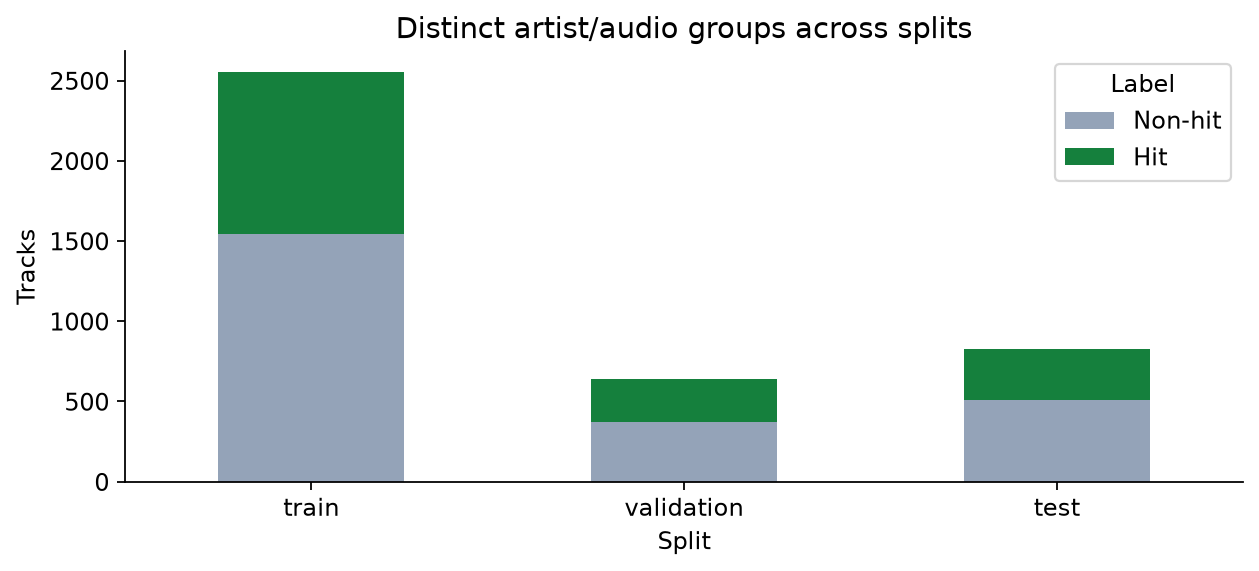

In [3]:
splits = split_data(tracks)
display(pd.DataFrame(metrics['splits']).T)
for a, b in [('train', 'validation'), ('train', 'test'), ('validation', 'test')]:
    overlap = set(tracks.iloc[splits[a]].group) & set(tracks.iloc[splits[b]].group)
    assert not overlap
print('Primary split check: no shared groups.')
display(Image(filename=str(ROOT / 'results/figures/data_splits.png')))

## 3. Explore training data
These distributions use training rows only. Histograms show associations and class overlap, not causal effects. The hit fraction is roughly 40%, which is a property of the source sample rather than the base rate of all new music releases.

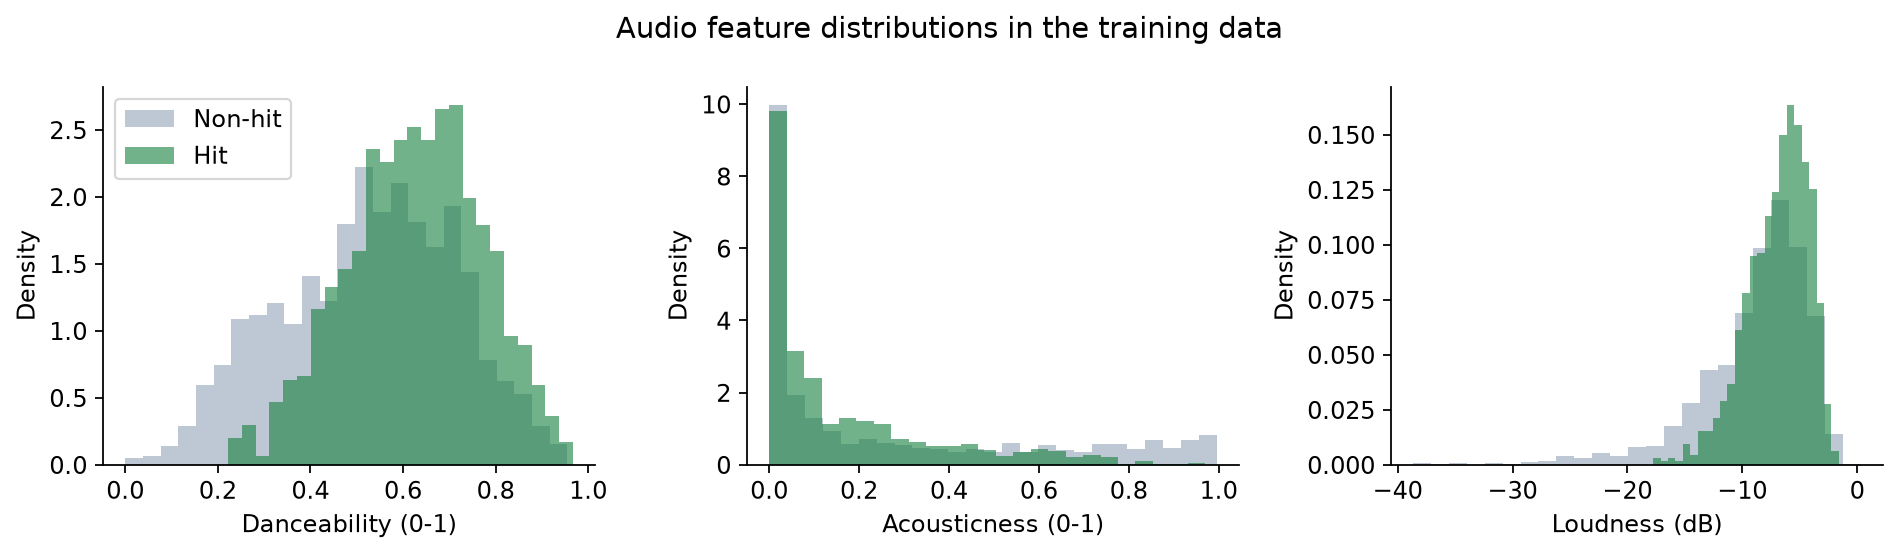

In [4]:
display(Image(filename=str(ROOT / 'results/figures/feature_distributions.png')))

## 4. Models and selection
The pipeline is median imputation, standardization and classification. There are no missing audio values in this snapshot, but imputation is fitted correctly inside the pipeline. Scaling matters for the linear, SVM and neural models and is harmless for the forest.

We compare five learned families and a majority baseline across nine fixed configurations. Logistic regression uses $p=1/(1+e^{-w^Tx-b})$. LDA models class distributions with a shared covariance estimate. The RBF SVM models nonlinear boundaries. The random forest averages tree scores. The neural model has one hidden layer of 16 units.

Selection uses the largest mean **3-fold training group CV ROC-AUC**. The test set does not select a model. Parameters and captured dependency notices are available in `src/train.py` and `results/metrics.json`.

,model,cv_auc_mean,cv_auc_std,fold_1_auc,fold_2_auc,fold_3_auc
0,Random forest depth=16,0.8010,0.0079,0.7899,0.8061,0.8070
1,Random forest depth=8,0.7958,0.0079,0.7849,0.7997,0.8029
2,Neural network (16),0.7867,0.0207,0.7595,0.7906,0.8099
3,RBF SVM C=1,0.7830,0.0146,0.7624,0.7933,0.7933
4,RBF SVM C=10,0.7759,0.0099,0.7632,0.7774,0.7872
5,Logistic regression C=1,0.7716,0.0217,0.7417,0.7806,0.7926
6,Logistic regression C=0.1,0.7713,0.0220,0.7406,0.7823,0.7911
7,Linear discriminant analysis,0.7655,0.0259,0.7289,0.7833,0.7844
8,Majority baseline,0.5000,0.0000,0.5000,0.5000,0.5000


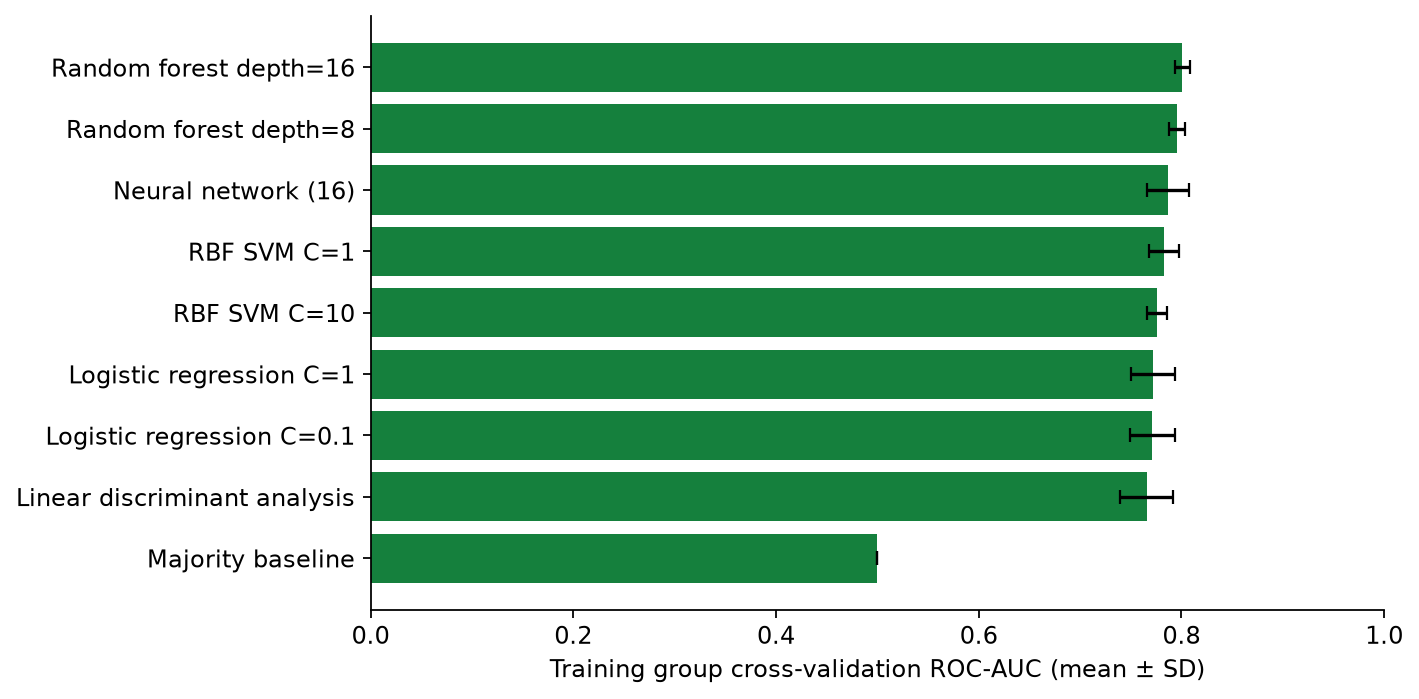

In [5]:
comparison = pd.read_csv(ROOT / 'results/model_comparison.csv')
display(comparison.round(4))
display(Image(filename=str(ROOT / 'results/figures/model_comparison.png')))

## 5. Validation threshold
We search thresholds 0.10-0.90 in steps of 0.01, maximizing validation F1. Ties prefer the threshold nearest 0.50. F1 is the harmonic mean of precision and recall. This objective favors finding hits and is not automatically the best objective for advertising expenditure.

In [6]:
thresholds = pd.read_csv(ROOT / 'results/threshold_search.csv')
display(thresholds.sort_values('validation_f1', ascending=False).head(8))
print('Chosen cutoff:', round(metrics['threshold'], 2))

,threshold,validation_f1
19,0.29,0.710791
18,0.28,0.709402
21,0.31,0.705710
20,0.30,0.705370
23,0.33,0.703428
22,0.32,0.702065
17,0.27,0.701408
24,0.34,0.700906


Chosen cutoff: 0.29


## 6. Untouched primary test results
The chosen threshold is 0.29. We also show the fixed 0.50 reference to explain trade-offs; it was not optimized using test outcomes. ROC-AUC and average precision evaluate ranking. A majority classifier's accuracy alone is misleading because it finds no hits.

,Selected cutoff,Fixed cutoff 0.50,Majority baseline
accuracy,0.7087,0.7476,0.6165
precision,0.5769,0.6824,0.0000
recall,0.9019,0.6392,0.0000
f1,0.7037,0.6601,0.0000
roc_auc,0.8136,0.8136,0.5000
average_precision,0.6809,0.6809,0.3835
brier_score,0.1700,0.1700,0.2366


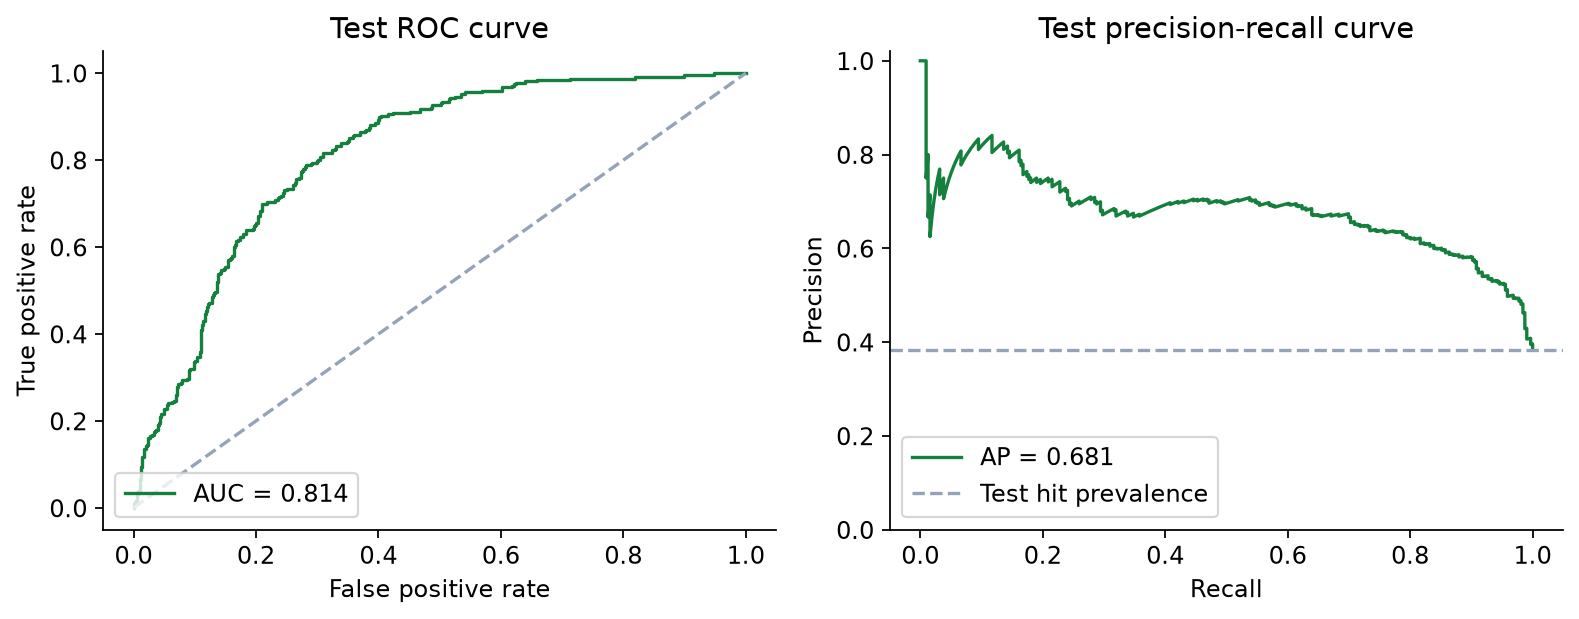

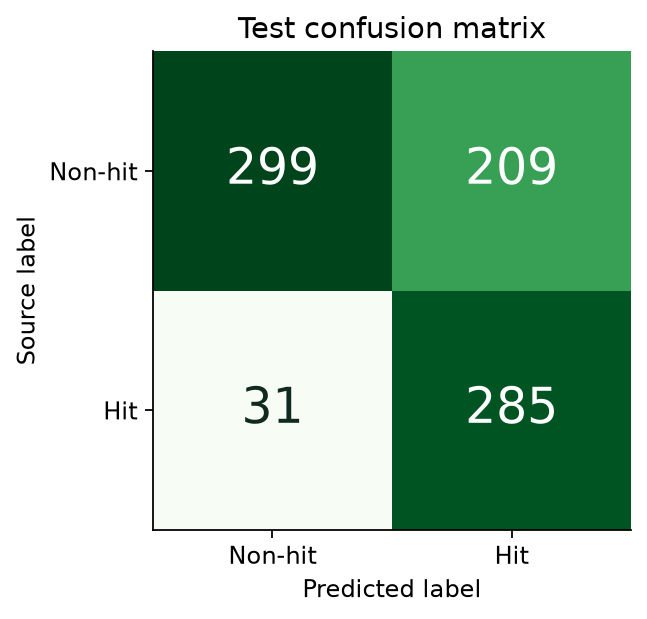

,2.5%,97.5%
roc_auc,0.7731,0.8478
f1,0.6542,0.7484
accuracy,0.6658,0.7491


In [7]:
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision', 'brier_score']
display(pd.DataFrame({
    'Selected cutoff': {k: metrics['test'][k] for k in metric_names},
    'Fixed cutoff 0.50': {k: metrics['test_at_0_5'][k] for k in metric_names},
    'Majority baseline': {k: metrics['baseline_test'][k] for k in metric_names}
}).round(4))
display(Image(filename=str(ROOT / 'results/figures/test_curves.png')))
display(Image(filename=str(ROOT / 'results/figures/confusion_matrix.png')))
display(pd.DataFrame(metrics['test_cluster_bootstrap_95_ci'], index=['2.5%', '97.5%']).T.round(4))

## 7. Interpretation and errors
At the selected cutoff the model catches 285 of 316 hit tracks, misses 31, and incorrectly calls 209 non-hits hits. High recall comes with modest precision. Training ROC-AUC is 0.982 versus test ROC-AUC 0.814, so overfitting remains.

Permutation importance shuffles one feature on validation data for 15 repeats. It measures predictive reliance in this fitted model. Correlations and the source sampling process can influence the ranking. Confidence intervals resample held-out groups 500 times and are conditional on the fitted model/split.

,feature,auc_drop_mean,auc_drop_std
0,Instrumentalness,0.1024,0.0124
1,Danceability,0.0392,0.0049
2,Acousticness,0.0384,0.0084
3,Loudness,0.0324,0.0100
4,Speechiness,0.0254,0.0065
5,Valence,0.0109,0.0043
6,Energy,0.0068,0.0036
7,Tempo,0.0022,0.0041
8,Liveness,0.0019,0.0048


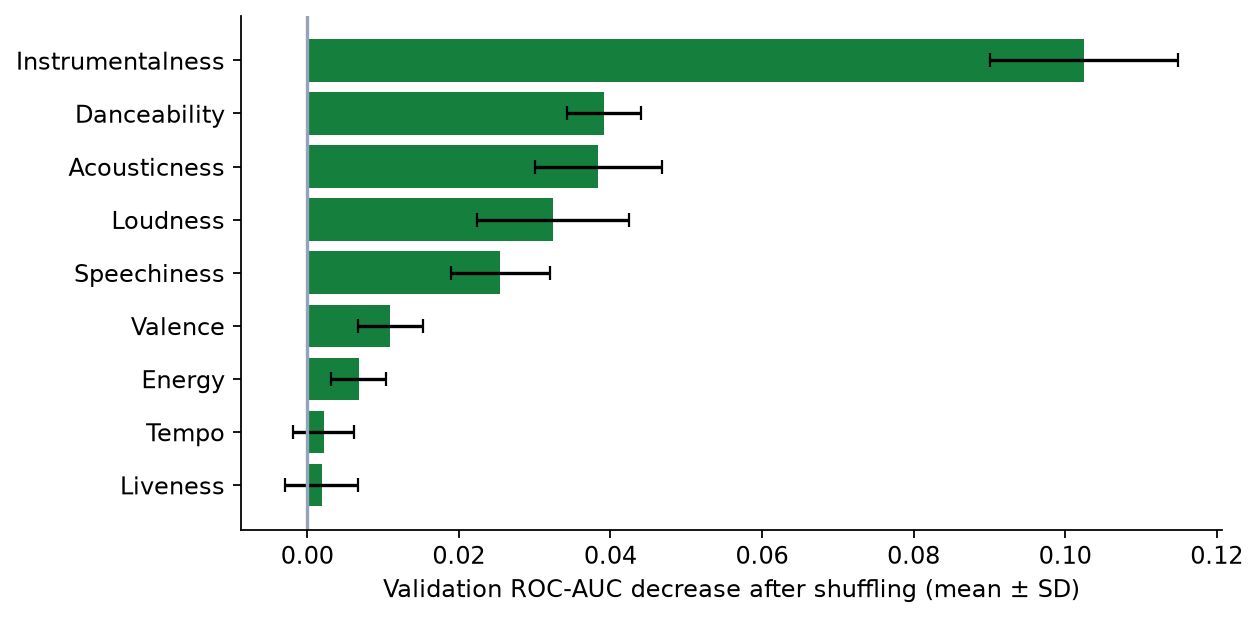

,row_id,Artist,Track,Label,group,score,prediction,correct,confidence
0,1125,goddess,sexual,1,1124,0.015,0,False,0.985
1,2886,susan boyle,wild horses,1,2875,0.030,0,False,0.970
2,1019,michael jackson,will you be there,1,254,0.030,0,False,0.970
3,682,metallica,cyanide,1,87,0.062,0,False,0.938
4,1996,pearl jam,given to fly,1,531,0.096,0,False,0.904
5,3063,the postal service,we will become silhouettes,1,3051,0.111,0,False,0.889
6,620,shades,serenade,1,620,0.121,0,False,0.879
7,3694,kid cudi,marijuana,1,893,0.127,0,False,0.873
8,1459,the prodigy,firestarter,1,1457,0.128,0,False,0.872
9,265,inxs,beautiful girl,1,199,0.131,0,False,0.869


In [8]:
display(pd.read_csv(ROOT / 'results/feature_importance.csv').round(4))
display(Image(filename=str(ROOT / 'results/figures/feature_importance.png')))
display(pd.read_csv(ROOT / 'results/error_examples.csv').head(10).round(3))

## 8. Row-split sensitivity diagnostic
The same chosen configuration is refitted for an ordinary random row split as a secondary diagnostic. It shares artists across splits and uses different sample sizes. It is not used for selecting the primary model, and the score difference does not isolate the causal effect of grouping.

In [9]:
display(pd.Series(metrics['random_split_diagnostic']))

metrics_at_0_5         {'accuracy': 0.7139303482587065, 'balanced_acc...
overlapping_artists                                                  392
train_rows                                                          3215
test_rows                                                            804
note                   Secondary diagnostic with more training data; ...
dtype: object

## 9. Reuse the trained model
The same prediction function powers the command-line tool and Streamlit app. Names and labels do not enter the predictor. The included examples are held-out rows selected in source order, not chosen only because they were correct.

In [10]:
demo = pd.read_csv(ROOT / 'data/demo_tracks.csv')
display(score_frame(demo)[['Artist', 'Track', 'Label', 'hit_score', 'predicted_label']].round(3))

,Artist,Track,Label,hit_score,predicted_label
0,debbie davies,little sister,0,0.634,1
1,a different breed of killer,the cleansing apparatus,0,0.117,0
2,the presets,truth and lies,0,0.078,0
3,shane minor,slave to the habit,1,0.747,1
4,wet wet wet,hear me now,0,0.582,1
5,beenie man,king of the dancehall,1,0.643,1
6,epmd,crossover,1,0.675,1
7,aretha franklin,a rose is still a rose,1,0.565,1


## 10. Conclusion and next experiment
Audio features carry useful signal for these historical labels, with test ROC-AUC 0.814. The recall-oriented cutoff finds most hits but flags many non-hits. Scores are not calibrated future-hit probabilities.

A stronger forecasting study should validate release dates and track identities, define chart entry within a fixed period after release, use representative non-hits, and evaluate on later releases. Only features known at prediction time should enter that study.

### References
- [Original HitPredict report and dataset link](https://cs229.stanford.edu/proj2018/report/16.pdf)
- [scikit-learn group cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- [scikit-learn leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html)
- [scikit-learn permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

The project includes AI-assisted implementation and documentation. The team's actual review, edits and individual contributions should be recorded in `docs/CONTRIBUTIONS.md`.